In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/Codveda level 3 task 1 2 3/churn-bigml-20 coddeva.csv")
test  = pd.read_csv("/content/drive/MyDrive/Codveda level 3 task 1 2 3/churn-bigml-80 coddeva.csv")

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nFirst 3 rows:\n{train.head(3)}")
print(f"\nDtypes:\n{train.dtypes}")

Train shape : (667, 20)
Test  shape : (2666, 20)

First 3 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95              228.5               83             19.42   
2             56.59              317.8               97             27.01   

   Total night minutes  Total night calls  Total night charge  \
0           

       Count  Percent
Churn                
False    572     85.8
True      95     14.2


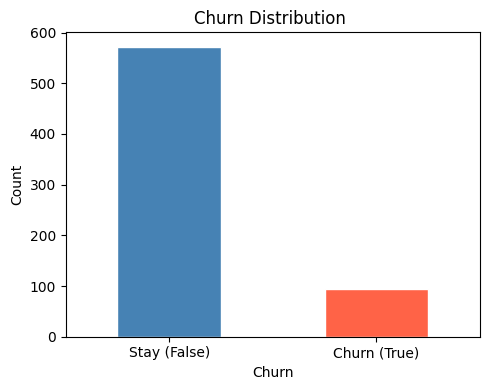

In [ ]:
churn_counts = train['Churn'].value_counts()
churn_pct    = train['Churn'].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': churn_counts, 'Percent': churn_pct.round(1)}))

plt.figure(figsize=(5, 4))
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title("Churn Distribution ")
plt.xticks([0, 1], ['Stay (False)', 'Churn (True)'], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(df):
    df = df.copy()

    # Standardize column names
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(" ", "_", regex=False))

    # Convert target to int
    df['churn'] = df['churn'].astype(int)

    # Drop State — 51 unique values, too many categories
    df.drop(columns=['state'], inplace=True)

    # Drop perfectly correlated columns (correlation = 1.00)
    # charge = minutes x rate → same information, redundant
    df.drop(columns=['total_day_charge',
                     'total_eve_charge',
                     'total_night_charge',
                     'total_intl_charge'], inplace=True)

    # Encode Yes/No columns to 1/0
    for col in ['international_plan', 'voice_mail_plan']:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # Encode area_code (3 unique values: 408, 415, 510)
    le = LabelEncoder()
    df['area_code'] = le.fit_transform(df['area_code'].astype(str))

    return df

train_clean = preprocess(train)
test_clean  = preprocess(test)

print("Columns after preprocessing:")
print(train_clean.columns.tolist())
print(f"\nTrain shape: {train_clean.shape}")
print(f"Test  shape: {test_clean.shape}")

Columns after preprocessing:
['account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_eve_minutes', 'total_eve_calls', 'total_night_minutes', 'total_night_calls', 'total_intl_minutes', 'total_intl_calls', 'customer_service_calls', 'churn']

Train shape: (667, 15)
Test  shape: (2666, 15)


In [ ]:
X_train = train_clean.drop(columns=['churn'])
y_train = train_clean['churn']

X_test  = test_clean.drop(columns=['churn'])
y_test  = test_clean['churn']

# StandardScaler: mean=0, std=1
# IMPORTANT: fit only on train, transform both
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")
print(f"\nFirst row scaled (first 5 features):\n{X_train_scaled[0, :5].round(4)}")

X_train: (667, 14)
X_test : (2666, 14)

First row scaled (first 5 features):
[ 0.3471 -1.4048 -0.2938 -0.6288 -0.6012]


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"✓ {name} trained")

✓ Logistic Regression trained
✓ Decision Tree trained
✓ Random Forest trained


In [ ]:
results = {}

print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("=" * 65)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score   (y_test, y_pred)
    f1   = f1_score       (y_test, y_pred)

    results[name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'y_pred'   : y_pred
    }

    print(f"{name:<25} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

print("=" * 65)

best_model_name = max(results, key=lambda k: results[k]['F1-Score'])
print(f"\nBest model (by F1): {best_model_name}")

Model                      Accuracy  Precision   Recall       F1
Logistic Regression          0.7637     0.3495   0.7242   0.4715
Decision Tree                0.9006     0.6606   0.6521   0.6563
Random Forest                0.8923     0.9316   0.2809   0.4317

Best model (by F1): Decision Tree


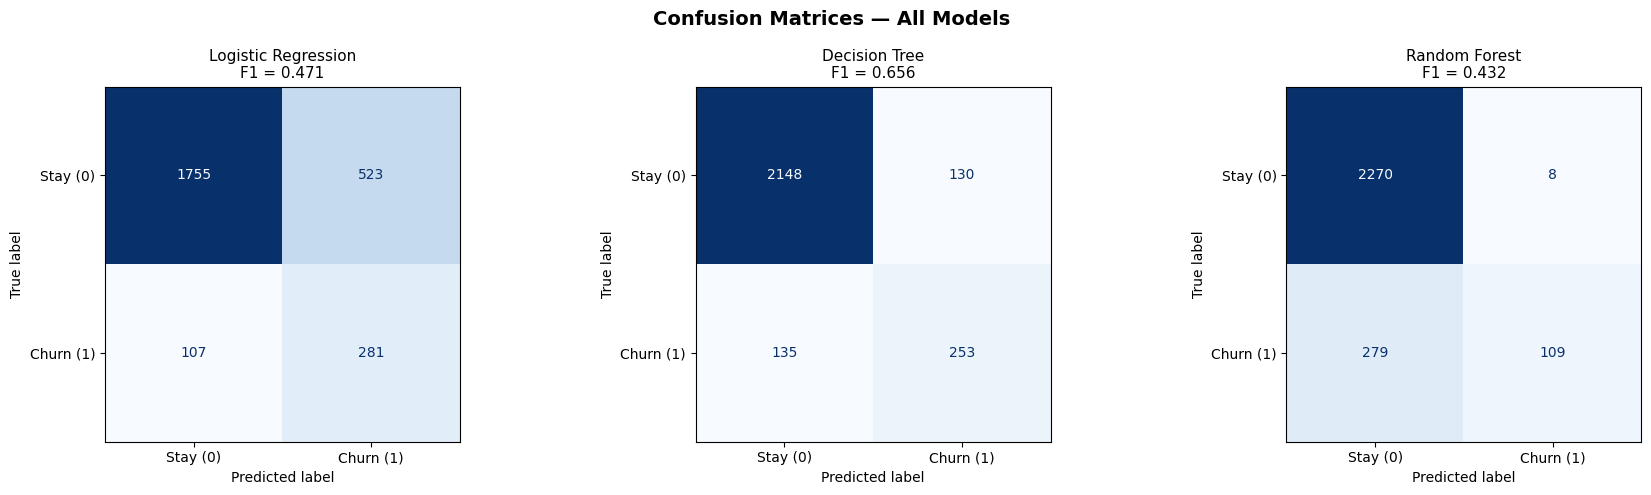

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nF1 = {res['F1-Score']:.3f}", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print(f"Detailed Report: {best_model_name}")
print("=" * 55)

print(classification_report(
    y_test,
    results[best_model_name]['y_pred'],
    target_names=['Stay (0)', 'Churn (1)']
))

Detailed Report: Decision Tree
              precision    recall  f1-score   support

    Stay (0)       0.94      0.94      0.94      2278
   Churn (1)       0.66      0.65      0.66       388

    accuracy                           0.90      2666
   macro avg       0.80      0.80      0.80      2666
weighted avg       0.90      0.90      0.90      2666



In [ ]:
print("GridSearchCV started...")

rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = rf_param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

GridSearchCV started...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters : {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1-Score: 0.6281


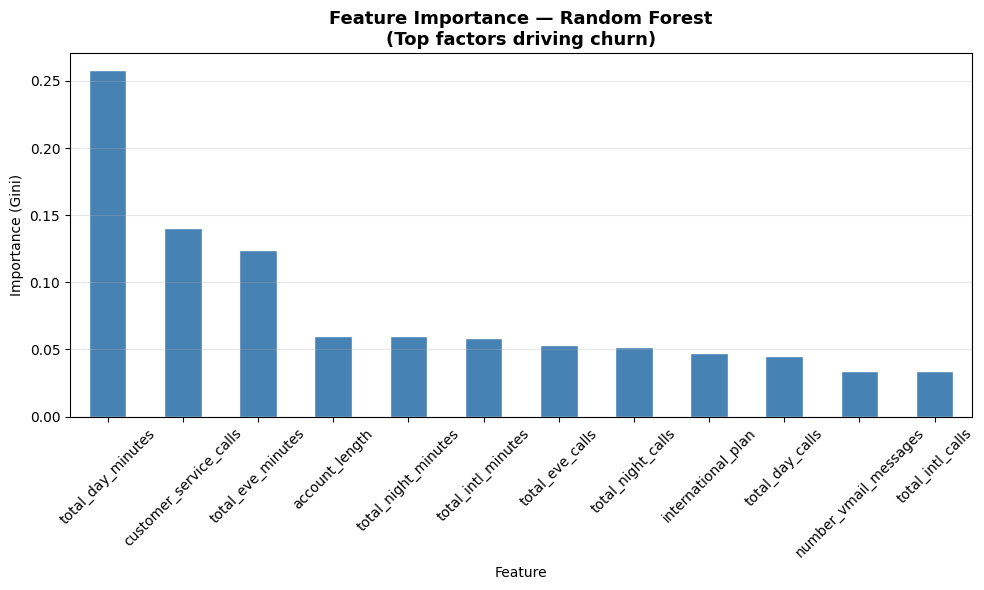


Top 5 most important features:
  total_day_minutes                   0.2578
  customer_service_calls              0.1406
  total_eve_minutes                   0.1243
  account_length                      0.0603
  total_night_minutes                 0.0599


In [ ]:
best_rf      = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(12).plot(
    kind='bar', ax=ax,
    color='steelblue', edgecolor='white'
)
ax.set_title("Feature Importance — Random Forest\n(Top factors driving churn)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Feature")
ax.set_ylabel("Importance (Gini)")
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for feat, imp in importances.head(5).items():
    print(f"  {feat:<35} {imp:.4f}")

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

best_rf      = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print("--- Tuned Random Forest --- ")
print(f"Accuracy  : {accuracy_score (y_test, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score   (y_test, y_pred_tuned):.4f}")
print(f"F1-Score  : {f1_score       (y_test, y_pred_tuned):.4f}")

--- Tuned Random Forest --- 
Accuracy  : 0.9055
Precision : 0.8269
Recall    : 0.4433
F1-Score  : 0.5772


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

best_rf      = grid_search.best_estimator_
y_proba      = best_rf.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.6, 0.05)

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("=" * 42)

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    p  = precision_score(y_test, y_pred_t, zero_division=0)
    r  = recall_score   (y_test, y_pred_t)
    f1 = f1_score       (y_test, y_pred_t)
    print(f"{t:>10.2f} {p:>10.4f} {r:>8.4f} {f1:>8.4f}")

 Threshold  Precision   Recall       F1
      0.10     0.2299   0.9124   0.3672
      0.15     0.3317   0.8789   0.4816
      0.20     0.4276   0.8531   0.5697
      0.25     0.5000   0.7938   0.6135
      0.30     0.5541   0.7397   0.6336
      0.35     0.6148   0.6830   0.6471
      0.40     0.6850   0.6108   0.6458
      0.45     0.7636   0.5412   0.6335
      0.50     0.8269   0.4433   0.5772
      0.55     0.8844   0.3351   0.4860


In [ ]:
# Select optimal threshold — best F1
best_t     = 0.0
best_f1    = 0.0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_t  = t

print(f"Optimal threshold : {best_t:.2f}")
print(f"Best F1-Score     : {best_f1:.4f}")

# Final evaluation with optimal threshold
y_pred_final = (y_proba >= best_t).astype(int)

print("\n--- Final Model (Threshold Tuned) ---")
print(f"Accuracy  : {accuracy_score (y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score   (y_test, y_pred_final):.4f}")
print(f"F1-Score  : {f1_score       (y_test, y_pred_final):.4f}")

print("\n--- Before vs After Threshold Tuning ---")
print(f"{'Metric':<12} {'Default (0.5)':>14} {'Tuned':>10}")
print("=" * 38)
metrics = {
    'Precision': (precision_score(y_test, y_pred_tuned),
                  precision_score(y_test, y_pred_final)),
    'Recall'   : (recall_score   (y_test, y_pred_tuned),
                  recall_score   (y_test, y_pred_final)),
    'F1-Score' : (f1_score       (y_test, y_pred_tuned),
                  f1_score       (y_test, y_pred_final)),
}
for metric, (before, after) in metrics.items():
    change = "↑" if after > before else "↓"
    print(f"{metric:<12} {before:>14.4f} {after:>10.4f} {change}")

Optimal threshold : 0.35
Best F1-Score     : 0.6471

--- Final Model (Threshold Tuned) ---
Accuracy  : 0.8916
Precision : 0.6148
Recall    : 0.6830
F1-Score  : 0.6471

--- Before vs After Threshold Tuning ---
Metric        Default (0.5)      Tuned
Precision            0.8269     0.6148 ↓
Recall               0.4433     0.6830 ↑
F1-Score             0.5772     0.6471 ↑


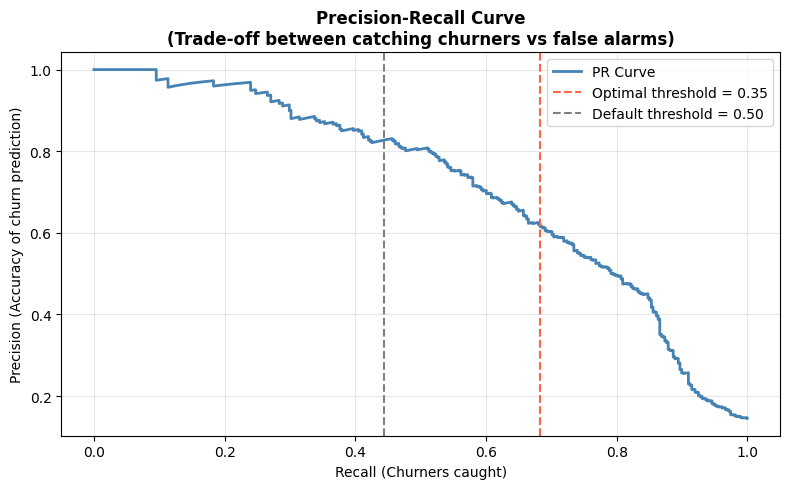

In [ ]:
precision_vals, recall_vals, thresh_vals = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_vals, precision_vals,
        color='steelblue', linewidth=2, label='PR Curve')
ax.axvline(x=recall_score(y_test, y_pred_final),
           color='tomato', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {best_t:.2f}')
ax.axvline(x=recall_score(y_test, y_pred_tuned),
           color='gray', linestyle='--', linewidth=1.5,
           label='Default threshold = 0.50')

ax.set_title("Precision-Recall Curve\n(Trade-off between catching churners vs false alarms)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Recall (Churners caught)")
ax.set_ylabel("Precision (Accuracy of churn prediction)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()